# Get the final plot and inference
----

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from get_model_probabilities import *
import scienceplots

from sidm_inference_on_data_and_models import infer_sidm, infer_sidm_interp, infer_sidm_fct, infer_sidm_latent
plt.style.use(["science","grid"])

DEFAULT ZS 2.28808070104492
Source redshift:2.2884950162268827


# Many ways to interpret so lets look at each one

x = 0.53 +0.82 -0.32
x = 0.52 +1.32 -0.37
x = 0.45 +1.04 -0.32
PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/output_to_model.pdf'.
$-0.34_{-0.52}^+{0.52}


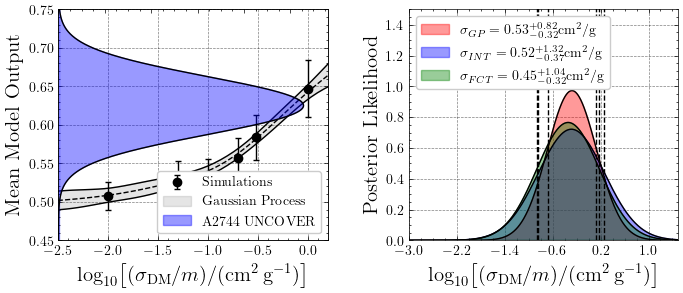

In [18]:
ifilter = 'concat'

models, probs = pkl.load(open("pickles/probs_for_cross_concat_nob1.pkl","rb"))
models, probabilities, probabilities_noise =pkl.load(open("pickles/model_on_data.pkl","rb"))
nmodels = len(probs['0.00'])

all_thresholds = []
for imodel in range(nmodels):
    #Get the X and y values for a given model
    all_thresholds.append(1.-np.array([ np.mean(probs[i][imodel]) for i in probs.keys()]))
    
all_thresholds = np.array(all_thresholds)
thresholds = np.mean(all_thresholds,axis=0)
err = return_error_in_mean(all_thresholds)

cross = np.array([float(i) for i in probs.keys() ])

est = infer_sidm(
    probabilities['concat'],
    { icross:thresholds[icx] for icx, icross in enumerate(cross)},
    return_all=True)


    
gp = est['gp']

fig, axarr = plt.subplots(1,2,figsize=(8,3))

fig.subplots_adjust(wspace=0.3)
#####################
handles = []
###PLOT 1

#####################
ax = axarr[0]
handles.append(ax.errorbar(np.log10(cross),thresholds,err,fmt='ko',capsize=2,label='Simulations'))
#ax.plot( cdm_cross[-1], cdm_thresh[-1], 'k*', ms=10)

xplot=np.linspace(-5.4,1,100)
gp_prediction, std = gp.predict(xplot.reshape(-1, 1), return_std=True)

ax.plot( xplot, gp_prediction,'k--')
handles.append(ax.fill_between( xplot, gp_prediction-std, gp_prediction+std, alpha=0.1, color='k',label='Gaussian Process'))
ax.plot( xplot, gp_prediction-std, color='k')
ax.plot( xplot, gp_prediction+std, color='k')

ax.set_ylim(0.45,0.75)
ax.set_xlim(-2.5,0.2)
ax.set_xlabel(
    r'$\log_{10}\!\left[(\sigma_{\rm DM}/m)/(\mathrm{cm}^2\,\mathrm{g}^{-1})\right]$', fontsize=15
)
ax.set_ylabel("Mean Model Output", fontsize=15)

#####################

###PLOT 2

#####################
ax = axarr[1]

xpdf = np.linspace(0.4,0.8,1000)
thresh = 1-probabilities['concat']



ypdf = np.prod([ norm.pdf(xpdf, i, np.std(probabilities['concat'])) for i in thresh ],axis=0)
ypdf /= np.sum(ypdf)*(xpdf[1]-xpdf[0])

ax = axarr[0].twiny()

xpdf = np.linspace(0.45,0.75,1000)
thresh = 1-probabilities[ifilter]
obsindivid = return_error_in_mean( probabilities[ifilter] ) * np.sqrt(30.)

ypdf = np.prod([ norm.pdf(xpdf, i, obsindivid) for i in thresh ],axis=0)
ypdf /= np.sum(ypdf)*(xpdf[1]-xpdf[0])

ax.plot(ypdf[::-1], xpdf[::-1], 'k-')
handles.append(ax.fill_between(ypdf, xpdf, alpha=0.4, label=f'A2744 UNCOVER', color='b'))
ax.set_xlim(0, ypdf.max()*1.1)
ax.set_ylim(0.45, 0.75)
ax.set_xticklabels([])
ax.grid(False)
ax.legend(handles=handles)
#####################


###PLOT 3

#####################

interpolate = infer_sidm_interp(
    probabilities['concat'],
    { icross:thresholds[icx] for icx, icross in enumerate(cross)},
)

functional = infer_sidm_fct(
    probabilities['concat'],
    { icross:thresholds[icx] for icx, icross in enumerate(cross)},
)

#latent = infer_sidm_latent()


label=[
    'GP','INT','FCT','LS'
]

different_methods = [
    est['estimates'],interpolate,functional
]
color=[
    'r','b','g','c'
]
for iInt, estimates in enumerate(different_methods):
    error = return_error_in_mean(estimates)
    
    xpdf = np.linspace(-10,10,10000)
    ypdf = norm.pdf(xpdf, np.mean(estimates),
                    return_error_in_mean(estimates))# #kde.pdf(xpdf)

    max_like = xpdf[np.argmax(ypdf)]
    
    cdf = cumulative_trapezoid(
        ypdf,
        xpdf,
        initial=0
    )
    max_like= xpdf[ np.argmax( ypdf)]

    cdf /= cdf[-1]

    low_value = cdf[ np.argmax(ypdf)] - 0.34
    hig_value = cdf[ np.argmax(ypdf)] + 0.34


    low = np.interp(
        low_value,
        cdf,
        xpdf
    )
    high = np.interp(
        hig_value,
        cdf,
        xpdf
    )
    ax = axarr[1]

    
    error = np.array([max_like - low, high - max_like])

    x = 10**max_like
    x_plus = 10**(max_like + error[1]) - x
    x_minus = x - 10**(max_like - error[0])
    ax.fill_between(
        xpdf, 
        ypdf, 
        alpha=0.4, color=color[iInt],
       label=f"$\sigma_{{{label[iInt]}}}={x:0.2f}^{{+{x_plus:0.2f}}}_{{-{x_minus:0.2f}}}$cm$^2$/g")

    print(f"x = {x:.2f} +{x_plus:.2f} -{x_minus:.2f}")



    ax.plot(xpdf, ypdf,'k-')
    ax.plot([low]*2,[0,2],'k--')
    ax.plot([high]*2,[0,2],'k--')

ax.set_xlabel(
    r'$\log_{10}\!\left[(\sigma_{\rm DM}/m)/(\mathrm{cm}^2\,\mathrm{g}^{-1})\right]$', fontsize=15
)
ax.set_ylabel("Posterior Likelihood", fontsize=15)
ax.legend(loc=2)
ax.set_xlim(-3, 1.5)
ax.set_xticks(np.linspace(-3,1,6))
ax.set_ylim(0, 1.5)

fig.align_ylabels()
filename = "plots/output_to_model.pdf"
plt.savefig(filename)
os.system("pdfcrop %s %s" % ( filename, filename))  
print(f"${max_like.real:0.2f}_{{-{error[0].real:0.2f}}}^+{{{error[1].real:0.2f}}}")
